In [15]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm


In [16]:
# results in FASTA form into dataframe

def pfam_results(results_input):
    data = {'accession': [], 'taxon': [], 'seq identifier': [], 'I Helix': []}
    with open(results_input) as fp:
        for record in SeqIO.parse(fp, "fasta"):
            seqident = re.findall(r"\|(?P<sequence_id>\w+)\|", record.id)
            accession = record.description
            taxon = re.findall(r"OX=(\d+)", record.description)
            sequence = str(record.seq)

            # attaching to dictionary
            data['seq identifier'].append(", ".join(seqident))
            data['accession'].append(accession)
            data['taxon'].append(", ".join(taxon))
            data['I Helix'].append(sequence)

    df = pd.DataFrame.from_dict(data)
    return df

In [17]:
# Converting HMM search output for pfam data to FASTA file
input = '/home/alecia/chapter3-repo/output/hmm_search_1/pfam/3/ihelixhits_e_0p001_z__T_.aln'
outfile_fasta = '/home/alecia/chapter3-repo/output/hmm_search_1/pfam/3/ihelixhits_e_0p001_z__T_.fasta'

with open(input) as infile:
    alignment = AlignIO.read(infile, 'stockholm')

SeqIO.write(alignment, outfile_fasta, 'fasta')

162084

In [18]:
pfam_r1 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_1/pfam/3/ihelixhits_e_0p001_z__T_.fasta')

In [19]:
pfam_r1

,accession,taxon,seq identifier,I Helix
0,tr|A0A498MRP4|A0A498MRP4_LABRO/720-751 [subseq...,84645,A0A498MRP4,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
1,tr|A0A498MRP4|A0A498MRP4_LABRO/1166-1197 [subs...,84645,A0A498MRP4,-EGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
2,tr|A0A498MRP4|A0A498MRP4_LABRO/1618-1649 [subs...,84645,A0A498MRP4,-DGLVIICL-DV-I-EA--G---TET--T--T-T--TLR-WGLLFMIKY
3,tr|A0A498MRP4|A0A498MRP4_LABRO/2174-2205 [subs...,84645,A0A498MRP4,-DGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
4,tr|A0A498MRP4|A0A498MRP4_LABRO/2626-2657 [subs...,84645,A0A498MRP4,-DGLVISCL-DV-I-EA--G---SET--T--A-T--TLR-WGLLFMIKY
...,...,...,...,...
162079,tr|A0A2S3GQM6|A0A2S3GQM6_9POAL/311-340 [subseq...,206008,A0A2S3GQM6,---LRDFCI-SF-V-LA--G---RDT--S--S-V--ALA-WFFWLLASH
162080,tr|A0A8X7P7K3|A0A8X7P7K3_BRACI/295-322 [subseq...,52824,A0A8X7P7K3,-----RECK-LF-Y-FA--G---QET--T--S-V--LLV-WTMILLSHH
162081,tr|A0A7S8A7J9|A0A7S8A7J9_9BRAD/226-256 [subseq...,1325114,A0A7S8A7J9,-DEMVSMVF-LL-L-AA--G---SET--T--T-H--LIS-GSAYELLR-
162082,tr|A0A395IRT2|A0A395IRT2_9HELO/207-235 [subseq...,38457,A0A395IRT2,---ILANMI-TF-L-IA--G---HET--I--S-G--ILS-FVFLNLMK-


In [20]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x

result_data = []

for index, row in pfam_r1.iterrows():
    acid = row['I Helix'][24]
    alc = row['I Helix'][25]

    # Append a dictionary with relevant information to the result_data list
    result_data.append({
        'accession': row['accession'],
        'sequence': row['I Helix'],
        'seq identifier': row['seq identifier'],
        'acid': acid,
        'alc': alc,
        'taxon': row['taxon'],
    })


# Create a DataFrame from the result_data list
result_df = pd.DataFrame(result_data)


In [21]:
result_df

,accession,sequence,seq identifier,acid,alc,taxon
0,tr|A0A498MRP4|A0A498MRP4_LABRO/720-751 [subseq...,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645
1,tr|A0A498MRP4|A0A498MRP4_LABRO/1166-1197 [subs...,-EGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645
2,tr|A0A498MRP4|A0A498MRP4_LABRO/1618-1649 [subs...,-DGLVIICL-DV-I-EA--G---TET--T--T-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645
3,tr|A0A498MRP4|A0A498MRP4_LABRO/2174-2205 [subs...,-DGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645
4,tr|A0A498MRP4|A0A498MRP4_LABRO/2626-2657 [subs...,-DGLVISCL-DV-I-EA--G---SET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645
...,...,...,...,...,...,...
162079,tr|A0A2S3GQM6|A0A2S3GQM6_9POAL/311-340 [subseq...,---LRDFCI-SF-V-LA--G---RDT--S--S-V--ALA-WFFWLLASH,A0A2S3GQM6,D,T,206008
162080,tr|A0A8X7P7K3|A0A8X7P7K3_BRACI/295-322 [subseq...,-----RECK-LF-Y-FA--G---QET--T--S-V--LLV-WTMILLSHH,A0A8X7P7K3,E,T,52824
162081,tr|A0A7S8A7J9|A0A7S8A7J9_9BRAD/226-256 [subseq...,-DEMVSMVF-LL-L-AA--G---SET--T--T-H--LIS-GSAYELLR-,A0A7S8A7J9,E,T,1325114
162082,tr|A0A395IRT2|A0A395IRT2_9HELO/207-235 [subseq...,---ILANMI-TF-L-IA--G---HET--I--S-G--ILS-FVFLNLMK-,A0A395IRT2,E,T,38457


In [22]:
acidalc = result_df.groupby('acid').alc.value_counts()
acidalc.to_csv('pfam_r1_allacidalc.csv')

# Manually removed the - T from the csv file

In [23]:
count = pd.read_csv('/home/alecia/chapter3-repo/analysis/pfam_heatmap/pfam_r1_allacidalc.csv')
count

,acid,alc,count
0,A,T,400
1,A,N,301
2,A,A,6
3,A,S,5
4,A,F,1
...,...,...,...
62,V,T,937
63,V,A,6
64,V,S,4
65,X,T,9


In [29]:
heatmap_data = (count.pivot(index='alc', columns='acid', values='count')
                .fillna(0)
)
heatmap_orderedAA = (heatmap_data.reindex(columns=['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .reindex(['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .fillna(0)
)
heatmap_orderedAA

acid,E,D,H,K,R,G,P,C,A,I,V,L,M,F,Y,W,Q,S,N,T
alc,,,,,,,,,,,,,,,,,,,,
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
R,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P,156.0,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,1321.0,216.0,1.0,0.0,0.0,4.0,0.0,0.0,6.0,2.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0


[Text(0.5, 23.52222222222222, 'Acid'),
 Text(50.722222222222214, 0.5, 'Alcohol')]

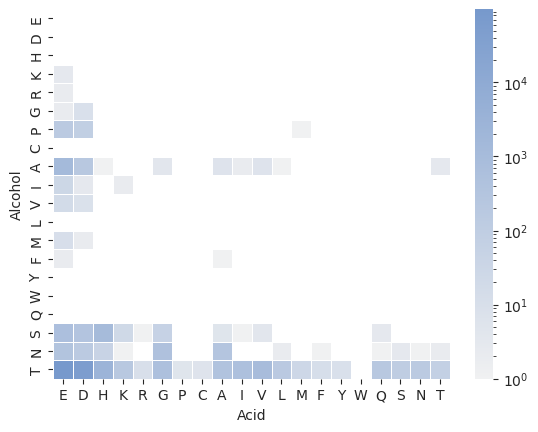

In [30]:
cmap = sns.light_palette("#79C", as_cmap=True)
sns.set_style(style='ticks')
sns.axes_style({'font.sans-serif': 'Arial'})

heatmap = sns.heatmap(
    heatmap_orderedAA,
    norm=LogNorm(),
    linecolor='white',
    linewidths=0.5,
    cmap=cmap
    )

heatmap.set(xlabel="Acid", ylabel="Alcohol")
